# Input Modeling:
- Locations represent delivery points including warehouse.
- Distance matrix represents travel cost between locations.
- Parcels include value, weight, and delivery time constraint.
- Vehicle has limited carrying capacity.

In [1]:
# Step 1: Input Modeling

# Locations (0 = warehouse)
locations = ["Warehouse", "A", "B", "C", "D"]

# Distance matrix (graph)
distance = [
    [0, 10, 15, 20, 25],
    [10, 0, 35, 25, 17],
    [15, 35, 0, 30, 28],
    [20, 25, 30, 0, 23],
    [25, 17, 28, 23, 0]
]

# Parcels: (location, value, weight, delivery_time_limit)
parcels = [
    ("A", 100, 5, 10),
    ("B", 60, 3, 8),
    ("C", 120, 7, 15),
    ("D", 80, 4, 12)
]

# Vehicle constraints
max_capacity = 10

print("Locations:", locations)
print("Distance Matrix:")
for row in distance:
    print(row)

print("\nParcels:")
for p in parcels:
    print(p)

print("\nVehicle Capacity:", max_capacity)

Locations: ['Warehouse', 'A', 'B', 'C', 'D']
Distance Matrix:
[0, 10, 15, 20, 25]
[10, 0, 35, 25, 17]
[15, 35, 0, 30, 28]
[20, 25, 30, 0, 23]
[25, 17, 28, 23, 0]

Parcels:
('A', 100, 5, 10)
('B', 60, 3, 8)
('C', 120, 7, 15)
('D', 80, 4, 12)

Vehicle Capacity: 10


# Recurrence Logic:
- The function explores all possible routes recursively.
- Base case: all locations visited → return to warehouse.
- Recursive case: try all unvisited cities and choose minimum cost.
- This demonstrates exponential complexity similar to TSP.

In [2]:
# Step 2: Recurrence-based Route Cost

def route_cost(current, visited):
    
    # If all locations visited → return to warehouse
    if len(visited) == len(distance):
        return distance[current][0]   # back to warehouse
    
    min_cost = float('inf')
    
    # Try all unvisited locations
    for next_city in range(len(distance)):
        if next_city not in visited:
            
            cost = distance[current][next_city] + \
                   route_cost(next_city, visited + [next_city])
            
            min_cost = min(min_cost, cost)
    
    return min_cost


# Start from warehouse (index 0)
result = route_cost(0, [0])

print("Minimum Route Cost:", result)

Minimum Route Cost: 95


# Greedy Strategy:
- Parcels are selected based on value-to-weight ratio.
- Higher ratio means more profit per unit weight.
- Greedy approach gives quick and efficient solution.
- It may not always be globally optimal but works well in practice.

In [3]:
# Step 3: Greedy Parcel Selection

# Sort parcels by value/weight ratio
sorted_parcels = sorted(parcels, key=lambda x: x[1]/x[2], reverse=True)

selected = []
total_weight = 0
total_value = 0

for p in sorted_parcels:
    location, value, weight, time_limit = p
    
    if total_weight + weight <= max_capacity:
        selected.append(p)
        total_weight += weight
        total_value += value

print("Selected Parcels:")
for s in selected:
    print(s)

print("\nTotal Weight:", total_weight)
print("Total Value:", total_value)

Selected Parcels:
('A', 100, 5, 10)
('B', 60, 3, 8)

Total Weight: 8
Total Value: 160


# Dynamic Programming Insight:
- Delivery is validated based on time constraints.
- Travel time is accumulated step by step.
- Only parcels delivered within time limit are accepted.
- This ensures realistic scheduling in logistics.

In [4]:
# Step 4: DP for Time Window Validation

def check_delivery(parcels, distance):
    
    current_time = 0
    current_location = 0  # warehouse
    
    delivered = []
    
    for p in parcels:
        loc, value, weight, time_limit = p
        
        # Get index of location
        loc_index = locations.index(loc)
        
        # Travel time
        travel_time = distance[current_location][loc_index]
        
        current_time += travel_time
        
        # Check if delivered within time
        if current_time <= time_limit:
            delivered.append(p)
            current_location = loc_index
        else:
            print(f"Parcel {loc} missed time window")
    
    return delivered


# Run using selected parcels from Step 3
valid_deliveries = check_delivery(selected, distance)

print("\nDelivered Parcels:")
for d in valid_deliveries:
    print(d)

Parcel B missed time window

Delivered Parcels:
('A', 100, 5, 10)


# Graph Algorithms:
- Dijkstra finds shortest path from warehouse to all locations.
- MST connects all locations with minimum total cost.
- These algorithms help optimize delivery routes.

In [5]:
# Step 5: Dijkstra Algorithm

import heapq

def dijkstra(distance, start):
    n = len(distance)
    dist = [float('inf')] * n
    dist[start] = 0
    
    pq = [(0, start)]
    
    while pq:
        current_dist, u = heapq.heappop(pq)
        
        for v in range(n):
            if u != v:
                new_dist = current_dist + distance[u][v]
                
                if new_dist < dist[v]:
                    dist[v] = new_dist
                    heapq.heappush(pq, (new_dist, v))
    
    return dist


# Run
shortest_paths = dijkstra(distance, 0)

print("Shortest distances from Warehouse:")
for i, d in enumerate(shortest_paths):
    print(f"{locations[i]}: {d}")

Shortest distances from Warehouse:
Warehouse: 0
A: 10
B: 15
C: 20
D: 25


In [6]:
# Prim's Algorithm (MST)

def prim_mst(distance):
    n = len(distance)
    visited = [False] * n
    visited[0] = True
    
    edges = []
    total_cost = 0
    
    for _ in range(n-1):
        min_edge = float('inf')
        x = y = -1
        
        for i in range(n):
            if visited[i]:
                for j in range(n):
                    if not visited[j] and distance[i][j] < min_edge:
                        min_edge = distance[i][j]
                        x, y = i, j
        
        visited[y] = True
        edges.append((x, y, min_edge))
        total_cost += min_edge
    
    return edges, total_cost


# Run
mst_edges, mst_cost = prim_mst(distance)

print("\nMST Edges:")
for e in mst_edges:
    print(e)

print("Total MST Cost:", mst_cost)


MST Edges:
(0, 1, 10)
(0, 2, 15)
(1, 4, 17)
(0, 3, 20)
Total MST Cost: 62


# TSP Analysis:
- TSP finds the optimal route visiting all locations.
- It checks all possible permutations.
- Time complexity is O(n!), making it expensive for large inputs.
- Suitable only for small number of locations.

In [7]:
# Step 6: TSP (Brute Force)

import itertools

def tsp(distance):
    n = len(distance)
    cities = list(range(1, n))  # exclude warehouse (0)
    
    min_cost = float('inf')
    best_route = None
    
    for perm in itertools.permutations(cities):
        route = [0] + list(perm) + [0]
        
        cost = 0
        for i in range(len(route)-1):
            cost += distance[route[i]][route[i+1]]
        
        if cost < min_cost:
            min_cost = cost
            best_route = route
    
    return best_route, min_cost


# Run
route, cost = tsp(distance)

print("Best Route:", route)
print("Minimum Distance:", cost)

Best Route: [0, 1, 4, 3, 2, 0]
Minimum Distance: 95


# Visualization & Profiling:
- Execution time increases with number of locations.
- TSP shows exponential growth.
- Graph visualization helps understand delivery route clearly.
- Visual tools help validate correctness of algorithm.

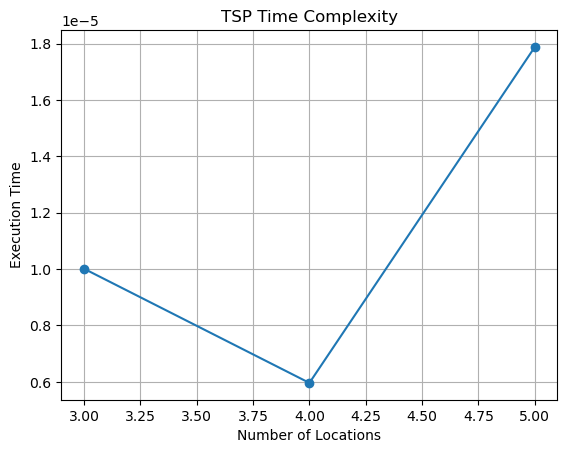

In [9]:
import time
import matplotlib.pyplot as plt

sizes = [3, 4, 5]

times = []

for n in sizes:
    small_matrix = [row[:n] for row in distance[:n]]
    
    start = time.time()
    tsp(small_matrix)
    times.append(time.time() - start)

plt.plot(sizes, times, marker='o')
plt.xlabel("Number of Locations")
plt.ylabel("Execution Time")
plt.title("TSP Time Complexity")
plt.grid()

plt.show()

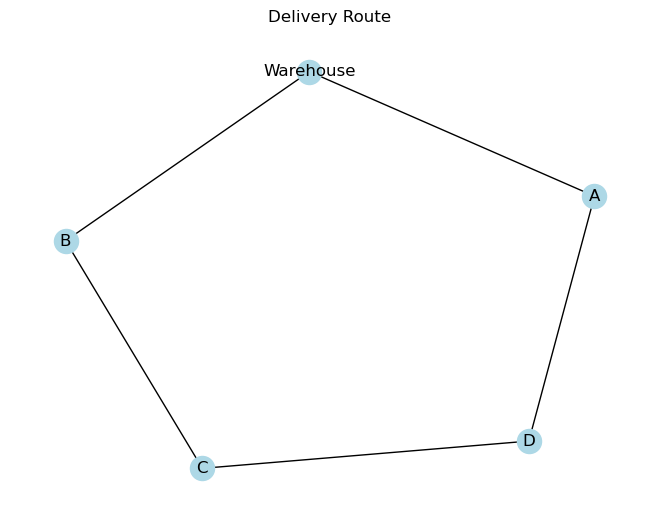

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Add nodes
for i in range(len(locations)):
    G.add_node(i, label=locations[i])

# Add edges from TSP route
for i in range(len(route)-1):
    G.add_edge(route[i], route[i+1])

labels = {i: locations[i] for i in range(len(locations))}

nx.draw(G, labels=labels, with_labels=True, node_color='lightblue')
plt.title("Delivery Route")
plt.show()

# Observations:
- Backtracking provides exact solutions but is slow for large inputs.
- Greedy approach is fast but may not give optimal results.
- Dynamic Programming helps handle constraints like delivery time.
- Dijkstra efficiently computes shortest paths.
- MST minimizes total connection cost.
- TSP gives optimal route but is computationally expensive.

# Analysis:
- Different algorithms serve different purposes in the system.
- Combining multiple strategies improves overall efficiency.
- TSP becomes infeasible as number of locations increases.
- Greedy and DP help reduce complexity in real-world scenarios.

# Conclusion:
- The delivery routing problem can be solved using multiple algorithmic approaches.
- Each technique contributes to solving a specific part of the problem.
- Hybrid approach provides better performance than a single method.
- This project demonstrates real-world application of algorithm design.